# Proyecto 2. Análisis Exploratorio
## Reto 11. Negocios: LMSYS Chatbot Arena Human Preference Predictions

**CC3084 Data Science | Universidad del Valle de Guatemala | Semestre II 2026**

| Integrante | Carné |
|---|---|
| Mia Alejandra Fuentes Mérida | 23775 |
| Roberto José Barreda Siekavizza | 23354 |
| Javier Eduardo España Pacheco | 23361 |
| Angel Esteban Esquit Hernández | 23221 |

---

## Introducción, Contexto y Carga Inicial de Datos

---
## 1. Situación Problemática

El surgimiento de los **Modelos de Lenguaje Grande (LLMs)** ha transformado radicalmente el panorama de los negocios digitales. Empresas como OpenAI, Google, Meta, Mistral y decenas de laboratorios más compiten lanzando modelos que prometen ser más capaces, más útiles y más alineados con las necesidades humanas. Sin embargo, esta proliferación genera un problema concreto para quienes deben tomar decisiones de negocio: **¿cómo saber cuál modelo es genuinamente mejor para sus usuarios?**

Las métricas técnicas tradicionales (perplexity, BLEU, ROUGE) no capturan bien la calidad percibida por usuarios reales. Por eso, la organización **LMSYS** (Large Model Systems Organization, UC Berkeley) creó **Chatbot Arena**: una plataforma donde usuarios anónimos interactúan simultáneamente con dos modelos LLM sin saber cuál es cuál, y al final votan por la respuesta que prefieren. Este enfoque, conocido como *blind pairwise evaluation* o evaluación por pares ciega, es considerado el estándar de oro para medir la calidad real de un LLM.

La relevancia de negocio es directa:

- **Costo operativo:** Distintos modelos tienen precios muy distintos por token (GPT-4o, Claude 3.5, Gemini Ultra vs. modelos open-source). Una empresa que integra LLMs en sus productos quiere el modelo con mejor relación calidad-precio desde la perspectiva del usuario final.
- **Experiencia de usuario:** En aplicaciones como asistentes virtuales, generación de contenido, soporte al cliente o educación, la preferencia humana es la métrica que más impacta la retención.
- **Estrategia de selección de modelos:** Anticipar la preferencia humana permite hacer *routing* inteligente: enviar queries simples a modelos baratos y queries complejos a modelos premium, optimizando costo y calidad.

Comprender **qué factores determinan que un usuario prefiera una respuesta sobre otra** es, por tanto, una pregunta de negocio con impacto económico real.

---
## 2. Problema Científico

> **¿Es posible identificar, a partir de características observables del prompt y de las respuestas generadas por dos LLMs, los patrones que predicen la preferencia humana en una evaluación ciega por pares?**

Esta pregunta engloba preguntas específicas exploradas durante el análisis:

- ¿La longitud de la respuesta influye en la preferencia del usuario?
- ¿Existen modelos sistemáticamente preferidos independientemente del oponente?
- ¿La posición del modelo (A o B) introduce sesgo en la evaluación?
- ¿Qué tipos de prompt generan más empates?
- ¿Existen diferencias estadísticamente significativas en el estilo de respuesta de los modelos ganadores?

---
## 3. Objetivos

### Objetivo General
Realizar un análisis exploratorio exhaustivo del dataset de Chatbot Arena para identificar patrones, variables relevantes y hallazgos que permitan comprender los factores que determinan la preferencia humana entre respuestas de modelos de lenguaje grande, sentando las bases para el desarrollo de un modelo predictivo.

### Objetivos Específicos

1. **Describir y caracterizar el dataset**: Identificar la estructura, tipos de variables, dimensiones, calidad de los datos (valores nulos, duplicados) y realizar las transformaciones de limpieza necesarias para el análisis.

2. **Analizar la distribución de variables cuantitativas y categóricas**: Estudiar la distribución de las longitudes de prompts y respuestas, la frecuencia de participación de cada modelo y la distribución del resultado (victoria de A, victoria de B, empate) mediante estadística descriptiva y visualizaciones.

3. **Identificar relaciones entre variables y el resultado**: Explorar correlaciones entre características de los textos (longitud, número de turnos) y el resultado de la batalla, detectar sesgos de posición y analizar qué modelos muestran mayor tasa de victoria, con el fin de generar hipótesis accionables para el modelado predictivo.

---
## 4. Descripción del Dataset

El dataset proviene de la competencia [LMSYS - Chatbot Arena Human Preference Predictions](https://www.kaggle.com/competitions/lmsys-chatbot-arena) en Kaggle.

Cada fila representa una **batalla** entre dos LLMs en la que un usuario humano evaluó ambas respuestas y emitió su preferencia. Los modelos compiten de forma anónima (el usuario no sabe cuál es cuál al momento de votar).

### Archivos del dataset

| Archivo | Descripción |
|---|---|
| `train.csv` | Batallas con el resultado (winner) etiquetado: datos de entrenamiento |
| `test.csv` | Batallas sin resultado: para predicción en la competencia |
| `sample_submission.csv` | Formato de entrega para Kaggle |

### Columnas de `train.csv`

| Columna | Tipo | Descripción |
|---|---|---|
| `id` | string | Identificador único de la batalla |
| `model_a` | string | Nombre del primer LLM en la batalla |
| `model_b` | string | Nombre del segundo LLM en la batalla |
| `prompt` | string (JSON list) | Turnos del prompt del usuario (puede ser multi-turno) |
| `response_a` | string (JSON list) | Respuestas generadas por `model_a` |
| `response_b` | string (JSON list) | Respuestas generadas por `model_b` |
| `winner_model_a` | int (0/1) | 1 si el usuario prefirió la respuesta de `model_a` |
| `winner_model_b` | int (0/1) | 1 si el usuario prefirió la respuesta de `model_b` |
| `winner_tie` | int (0/1) | 1 si el usuario declaró empate |

> **Nota:** Las tres columnas `winner_*` son mutuamente excluyentes. Exactamente una vale 1 en cada fila.

---
## 5. Configuración del Ambiente

In [58]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install -r ../requirements.txt

In [59]:
import sys
from pathlib import Path

# Agregar el directorio raíz al path para importar src/
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src import config as cfg
from src import load

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(' Librerías cargadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   ROOT    {ROOT}')

 Librerías cargadas correctamente
   pandas  3.0.5
   numpy   2.5.2
   ROOT    /home/javier-espana/Escritorio/CC3084-PRY2


---
## 6. Descarga del Dataset

El dataset se descarga desde Kaggle con `kagglehub`. Requiere una API key de Kaggle en
`~/.kaggle/kaggle.json` y haber aceptado las
[reglas de la competencia](https://www.kaggle.com/competitions/lmsys-chatbot-arena/rules).
El procedimiento para generar esa key está documentado en el `README.md` del repositorio.

La celda siguiente descarga los archivos solo si aún no están en `data/raw/`.


In [60]:
import kagglehub
import shutil

RAW_DIR = ROOT / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

ARCHIVOS_ESPERADOS = ['train.csv', 'test.csv', 'sample_submission.csv']
archivos_presentes = [f for f in ARCHIVOS_ESPERADOS if (RAW_DIR / f).exists()]

if len(archivos_presentes) == len(ARCHIVOS_ESPERADOS):
    # Los archivos ya existen: no se descarga nada
    print('Dataset ya disponible en data/raw/. No se requiere descarga.')
else:
    faltantes = [f for f in ARCHIVOS_ESPERADOS if f not in archivos_presentes]
    print(f'Archivos faltantes: {faltantes}')
    print('Iniciando descarga desde Kaggle...')

    kaggle_creds = Path.home() / '.kaggle' / 'kaggle.json'
    if not kaggle_creds.exists():
        raise FileNotFoundError(
            "No se encontro ~/.kaggle/kaggle.json.\n"
            "Seguir los pasos de la seccion 6 (celda markdown anterior) para configurarlo."
        )

    download_path = Path(kagglehub.competition_download('lmsys-chatbot-arena'))
    print(f'Descargado en: {download_path}')

    for f in download_path.glob('*.csv'):
        dest = RAW_DIR / f.name
        if not dest.exists():
            shutil.copy2(f, dest)
            print(f'  Copiado: {f.name}')

# Resumen de archivos disponibles
print('\nArchivos en data/raw/:')
for f in sorted(RAW_DIR.glob('*.csv')):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:30s}  {size_mb:7.1f} MB')


Dataset ya disponible en data/raw/. No se requiere descarga.

Archivos en data/raw/:
  sample_submission.csv               0.0 MB
  test.csv                            0.0 MB
  train.csv                         184.2 MB


---
## 7. Carga del Dataset

In [61]:
# Cargamos train.csv completo
df = load.load_train()
print(f'Shape de train.csv: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Shape de train.csv: 57,477 filas × 9 columnas


In [62]:
# Primeras filas
df.head(3)

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1


---
## 8. Primera Exploración del Dataset

In [63]:
# Tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              57477 non-null  int64
 1   model_a         57477 non-null  str  
 2   model_b         57477 non-null  str  
 3   prompt          57477 non-null  str  
 4   response_a      57477 non-null  str  
 5   response_b      57477 non-null  str  
 6   winner_model_a  57477 non-null  int64
 7   winner_model_b  57477 non-null  int64
 8   winner_tie      57477 non-null  int64
dtypes: int64(4), str(5)
memory usage: 3.9 MB


In [64]:
# Estadísticas de las columnas numéricas (columnas winner_*)
df[cfg.WINNER_COLS].describe()

,winner_model_a,winner_model_b,winner_tie
count,57477.000000,57477.000000,57477.000000
mean,0.349079,0.341911,0.309011
std,0.476683,0.474354,0.462090
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


In [65]:
# Conteo de valores nulos por columna
nulos = df.isnull().sum().rename('nulos')
nulos_pct = (df.isnull().mean() * 100).round(2).rename('% nulos')
pd.concat([nulos, nulos_pct], axis=1)

,nulos,% nulos
id,0,0.0
model_a,0,0.0
model_b,0,0.0
prompt,0,0.0
response_a,0,0.0
response_b,0,0.0
winner_model_a,0,0.0
winner_model_b,0,0.0
winner_tie,0,0.0


In [66]:
# Distribución de ganadores (rápido vistazo)
ganadores = pd.Series({
    'model_a gana': df[cfg.COL_WIN_A].sum(),
    'model_b gana': df[cfg.COL_WIN_B].sum(),
    'empate':       df[cfg.COL_WIN_TIE].sum(),
}, name='conteo')

ganadores_pct = (ganadores / len(df) * 100).round(2).rename('% del total')
resumen_ganadores = pd.concat([ganadores, ganadores_pct], axis=1)
print(resumen_ganadores.to_string())

              conteo  % del total
model_a gana   20064        34.91
model_b gana   19652        34.19
empate         17761        30.90


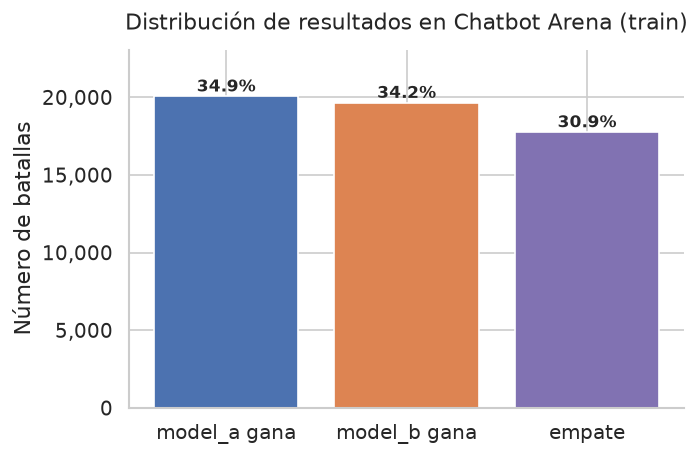

 Figura guardada en docs/figures/fig_distribucion_resultado.png


In [67]:
# Visualización rápida de la distribución de resultados
fig, ax = plt.subplots(figsize=(6, 4))
colores = ['#4C72B0', '#DD8452', '#8172B2']
bars = ax.bar(resumen_ganadores.index, resumen_ganadores['conteo'], color=colores, edgecolor='white')

for bar, pct in zip(bars, ganadores_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Distribución de resultados en Chatbot Arena (train)', fontsize=13, pad=12)
ax.set_ylabel('Número de batallas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, ganadores.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('../docs/figures/fig_distribucion_resultado.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figura guardada en docs/figures/fig_distribucion_resultado.png')

In [68]:
# Modelos únicos en el dataset
modelos_a = set(df[cfg.COL_MODEL_A].dropna().unique())
modelos_b = set(df[cfg.COL_MODEL_B].dropna().unique())
todos_modelos = modelos_a | modelos_b

print(f'Modelos únicos como model_a: {len(modelos_a)}')
print(f'Modelos únicos como model_b: {len(modelos_b)}')
print(f'Total de modelos distintos en el dataset: {len(todos_modelos)}')
print('\nListado de modelos:')
for m in sorted(todos_modelos):
    print(f'  {m}')

Modelos únicos como model_a: 64
Modelos únicos como model_b: 64
Total de modelos distintos en el dataset: 64

Listado de modelos:
  RWKV-4-Raven-14B
  alpaca-13b
  chatglm-6b
  chatglm2-6b
  chatglm3-6b
  claude-1
  claude-2.0
  claude-2.1
  claude-instant-1
  codellama-34b-instruct
  deepseek-llm-67b-chat
  dolly-v2-12b
  dolphin-2.2.1-mistral-7b
  falcon-180b-chat
  fastchat-t5-3b
  gemini-pro
  gemini-pro-dev-api
  gpt-3.5-turbo-0125
  gpt-3.5-turbo-0314
  gpt-3.5-turbo-0613
  gpt-3.5-turbo-1106
  gpt-4-0125-preview
  gpt-4-0314
  gpt-4-0613
  gpt-4-1106-preview
  gpt4all-13b-snoozy
  guanaco-33b
  koala-13b
  llama-13b
  llama-2-13b-chat
  llama-2-70b-chat
  llama-2-7b-chat
  llama2-70b-steerlm-chat
  mistral-7b-instruct
  mistral-7b-instruct-v0.2
  mistral-medium
  mixtral-8x7b-instruct-v0.1
  mpt-30b-chat
  mpt-7b-chat
  nous-hermes-2-mixtral-8x7b-dpo
  oasst-pythia-12b
  openchat-3.5
  openchat-3.5-0106
  openhermes-2.5-mistral-7b
  palm-2
  pplx-70b-online
  pplx-7b-online
  qw

---
## 9. Resumen de la Exploración Inicial

Esta primera lectura del archivo crudo deja ver con qué se está trabajando:

- Son **57,477 batallas** descritas por **9 columnas**, una fila por enfrentamiento entre dos
  modelos.
- **No hay valores nulos a nivel de celda** en ninguna de las nueve columnas. Eso no significa que no
  falten datos: `prompt`, `response_a` y `response_b` son *strings* con una lista JSON de turnos, así
  que un turno sin respuesta queda escondido como un `null` adentro de la lista y no como una celda
  vacía.
- Esas tres columnas de texto no se pueden analizar tal como vienen. Hay que deserializar el JSON
  para sacar el texto plano y contar turnos.
- El resultado viene repartido en tres columnas binarias en vez de una sola etiqueta, así que
  conviene derivar una variable objetivo unificada.
- El reparto del resultado está **balanceado**: 34.91% de victorias para el modelo en posición A,
  34.19% para el de posición B y 30.90% de empates. Que A y B queden tan cerca sugiere que el sesgo
  de posición, si lo hay, es chico.
- Compiten **64 modelos distintos**, desde familias comerciales como GPT-4, Claude, Gemini y PaLM-2
  hasta modelos abiertos como Llama-2, Mixtral, Vicuna, Qwen y Zephyr. Con tanta variedad de tamaños
  y generaciones, es esperable que la participación sea muy despareja.
